# Importing Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing all the required libraries

In [31]:
traindata = pd.read_csv("C:\\Users\\rohit\\OneDrive\\Desktop\\Movie Rating\\Data\\IMDb Movies India.csv")

In [32]:
traindata.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
traindata.info()

# Null Validation

In [33]:
traindata.isna().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [34]:
traindata.dropna(inplace = True)

# Data Visualisation

In [ ]:
testdata = traindata

In [ ]:
testdata['Genre'] = testdata['Genre'].str.split(', ')
testdata = testdata.explode('Genre')
testdata
#As the 'Genre column has multiple genres listed for the same movie, we convert these into an array using .split(',')
#We then use .explode('Genre') to form multiple rows with each element of the array

In [ ]:
gen_rating = testdata.groupby('Genre')['Rating'].mean().reset_index()
#we create a dataframe with 2 columns which are the genres and their average ratings
plt.figure(figsize=(12, 6))
plt.bar(gen_rating['Genre'], gen_rating['Rating'])
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.title('Average Rating by Genre')
plt.xticks(rotation=90)
#By default, the x-axis labels can be horizontal, hence rotating them by 90 degrees (making them vertical) can help avoid overlapping and improve readability.
plt.show()

In [ ]:
testdata['Votes'] = pd.to_numeric(testdata['Votes'], errors='coerce')
#We convert the data present under the 'Votes' column to numeric datatype.
bin_edges = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
bin_labels = ['0-100', '100-200', '200-300', '300-400', '400-500','500-600', '600-700', '700-800', '800-900', '900-1000']
testdata['Votes_Group'] = pd.cut(testdata['Votes'], bins=bin_edges, labels=bin_labels)
# Creating a new column in our dataframe which contains the group to which the numeric value under 'Votes' column belongs.
votes_rating = testdata.groupby('Votes_Group')['Rating'].mean().reset_index()
#we create a dataframe with 2 columns which are the votes group and their average ratings
plt.figure(figsize=(12, 6))
plt.bar(votes_rating['Votes_Group'], votes_rating['Rating'])
plt.xlabel('Votes_Group')
plt.ylabel('Average Rating')
plt.title('Average Rating by Votes_Group')
plt.show()
#below is a bar graph of how the average rating varies by the number of people that vote. We can see their isnt much fluctuation in the ratings even if a lot of people are voting

In [ ]:
testdata['Duration'] = testdata['Duration'].str.replace('min', '').astype(float)
bin_edges = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
bin_labels = ['0-30', '30-60', '60-90', '90-120', '120-150','150-180', '180-210', '210-240', '240-270', '270-300', '300-330']
testdata['duration_Group'] = pd.cut(testdata['Duration'], bins=bin_edges, labels=bin_labels)
duration_rating = testdata.groupby('duration_Group')['Rating'].mean().reset_index()
#we create a dataframe with 2 columns which are the duration groups and their average ratings
plt.figure(figsize=(12, 6))
plt.bar(duration_rating['duration_Group'], duration_rating['Rating'])
plt.xlabel('duration_Group')
plt.ylabel('Average Rating')
plt.title('Average Rating by duration_Group')
plt.show()
#we cans ee the variation in ratings as the duration of the movie varies

In [ ]:
testdata['Year'] = testdata['Year'].str.replace(r'[\(\)]', '').astype(int)
bin_edges = [1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030]
bin_labels = ['1930-1940', '1940-1950', '1950-1960', '1960-1970', '1970-1980','1980-1990', '1990-2000', '2000-2010', '2010-2020', '2020-2030']
testdata['year_Group'] = pd.cut(testdata['Year'], bins=bin_edges, labels=bin_labels)
year_rating = testdata.groupby('year_Group')['Rating'].mean().reset_index()
#we create a dataframe with 2 columns which are the duration groups and their average ratings
plt.figure(figsize=(12, 6))
plt.bar(year_rating['year_Group'], year_rating['Rating'])
plt.xlabel('year_Group')
plt.ylabel('Average Rating')
plt.title('Average Rating by year_Group')
plt.show()

# Feature Engineering

In [35]:
traindata['Genre']

1                            Drama
3                  Comedy, Romance
5           Comedy, Drama, Musical
6              Drama, Romance, War
8        Horror, Mystery, Thriller
                   ...            
15493                        Drama
15494    Biography, Drama, History
15503         Action, Crime, Drama
15505                Action, Drama
15508                Action, Drama
Name: Genre, Length: 5659, dtype: object

In [36]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
traindata['Genre'] = label_encoder.fit_transform(traindata['Genre'])
#giving numeric values to different genres

In [37]:
traindata.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,184,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,289,7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,320,5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [38]:
genre_mapping = {index: genre for index, genre in enumerate(label_encoder.classes_)}
genre_mapping

{0: 'Action',
 1: 'Action, Adventure',
 2: 'Action, Adventure, Biography',
 3: 'Action, Adventure, Comedy',
 4: 'Action, Adventure, Crime',
 5: 'Action, Adventure, Drama',
 6: 'Action, Adventure, Family',
 7: 'Action, Adventure, Fantasy',
 8: 'Action, Adventure, History',
 9: 'Action, Adventure, Horror',
 10: 'Action, Adventure, Musical',
 11: 'Action, Adventure, Mystery',
 12: 'Action, Adventure, Romance',
 13: 'Action, Adventure, Sci-Fi',
 14: 'Action, Adventure, Thriller',
 15: 'Action, Biography, Crime',
 16: 'Action, Biography, Drama',
 17: 'Action, Comedy',
 18: 'Action, Comedy, Crime',
 19: 'Action, Comedy, Drama',
 20: 'Action, Comedy, Fantasy',
 21: 'Action, Comedy, Horror',
 22: 'Action, Comedy, Musical',
 23: 'Action, Comedy, Mystery',
 24: 'Action, Comedy, Romance',
 25: 'Action, Comedy, Thriller',
 26: 'Action, Comedy, War',
 27: 'Action, Crime',
 28: 'Action, Crime, Drama',
 29: 'Action, Crime, Family',
 30: 'Action, Crime, Fantasy',
 31: 'Action, Crime, History',
 32: 'A

In [40]:
traindata['Director']

1          Gaurav Bakshi
3             Ovais Khan
5           Rahul Rawail
6         Shoojit Sircar
8          Allyson Patel
              ...       
15493        Mozez Singh
15494      Shyam Benegal
15503    S.P. Muthuraman
15505         Kuku Kohli
15508       K.C. Bokadia
Name: Director, Length: 5659, dtype: object

In [42]:
traindata['Director'].nunique()

2431

In [43]:
traindata['Director'] = label_encoder.fit_transform(traindata['Director'])

In [44]:
traindata.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,629,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,184,4.4,35,1335,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,1530,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,289,7.4,"1,086",2044,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,320,5.6,326,135,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [45]:
traindata["Actor 1"] = label_encoder.fit_transform(traindata["Actor 1"])

In [46]:
traindata["Actor 2"] = label_encoder.fit_transform(traindata["Actor 2"])

In [47]:
traindata["Actor 3"] = label_encoder.fit_transform(traindata["Actor 3"])

In [48]:
traindata.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,629,1352,2272,319
3,#Yaaram,(2019),110 min,184,4.4,35,1335,1198,719,2148
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,1530,378,75,2045
6,...Yahaan,(2005),142 min,289,7.4,"1,086",2044,692,1112,2524
8,?: A Question Mark,(2012),82 min,320,5.6,326,135,1934,1175,1013


In [49]:
columns_to_drop = ['Name', 'Duration', 'Votes', 'Year', 'Rating']

In [50]:
predictors = traindata.drop(columns_to_drop, axis = 1)
predictors

,Genre,Director,Actor 1,Actor 2,Actor 3
1,229,629,1352,2272,319
3,184,1335,1198,719,2148
5,157,1530,378,75,2045
6,289,2044,692,1112,2524
8,320,135,1934,1175,1013
...,...,...,...,...,...
15493,229,1223,1861,1801,1615
15494,133,2059,763,1619,1184
15503,28,1793,406,754,1685
15505,38,1025,112,2164,314


In [51]:
target = traindata['Rating']
target

1        7.0
3        4.4
5        4.7
6        7.4
8        5.6
        ... 
15493    6.1
15494    6.2
15503    5.8
15505    4.5
15508    6.2
Name: Rating, Length: 5659, dtype: float64

In [53]:
traindata.corr()

,Genre,Rating,Director,Actor 1,Actor 2,Actor 3
Genre,1.000000,0.121796,-0.017921,0.042745,0.028168,0.007474
Rating,0.121796,1.000000,-0.006824,0.023430,0.041353,0.042413
Director,-0.017921,-0.006824,1.000000,0.022918,0.018039,0.017915
Actor 1,0.042745,0.023430,0.022918,1.000000,-0.000642,0.013170
Actor 2,0.028168,0.041353,0.018039,-0.000642,1.000000,0.010439
Actor 3,0.007474,0.042413,0.017915,0.013170,0.010439,1.000000


In [54]:
traindata.describe()

,Genre,Rating,Director,Actor 1,Actor 2,Actor 3
count,5659.000000,5659.000000,5659.000000,5659.000000,5659.000000,5659.000000
mean,171.728221,5.898533,1211.864994,966.963598,1182.761442,1276.103375
std,108.208770,1.381165,686.698545,564.890824,666.834013,720.046925
min,0.000000,1.100000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,5.000000,637.000000,468.000000,617.000000,652.500000
50%,184.000000,6.100000,1198.000000,971.000000,1198.000000,1306.000000
75%,248.000000,6.900000,1793.000000,1472.000000,1767.500000,1868.500000
max,375.000000,10.000000,2430.000000,1959.000000,2320.000000,2555.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x1bc2b76fa90>,
 'caps': [<matplotlib.lines.Line2D at 0x1bc2b322190>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bc2b76f730>],
 'medians': [<matplotlib.lines.Line2D at 0x1bc2b322850>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bc2b322bb0>],
 'means': []}

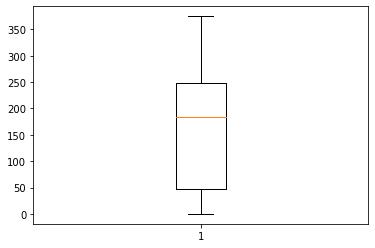

In [58]:
plt.boxplot(traindata['Genre']) 

{'whiskers': [<matplotlib.lines.Line2D at 0x1bc2a8ad430>,
 'caps': [<matplotlib.lines.Line2D at 0x1bc2a8adaf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bc2a8ad0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1bc2b8c8190>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bc2b8c84f0>],
 'means': []}

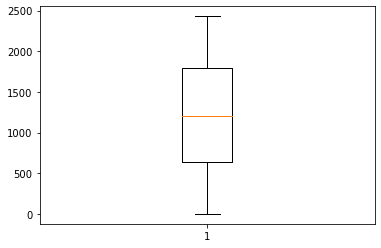

In [59]:
plt.boxplot(traindata['Director']) 

# Training the model

In [68]:
from sklearn.model_selection import train_test_split

In [75]:
x_train, y_test, x_value, y_value = train_test_split(predictors,target,test_size=0.33, random_state=0)

In [76]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_regressor = DecisionTreeRegressor(random_state=0)
decision_tree_regressor.fit(x_train, x_value)
y_pred = decision_tree_regressor.predict(y_test)

# Checking the accuracy

In [77]:
#For regression problems (predicting continuous values), typical evaluation metrics include Mean Squared Error (MSE)
# Calculate mean squared error (or other appropriate regression metric)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_value, y_pred)
print('Mean Squared Error:', mse)

Mean Squared Error: 3.424357601713062
